# Phase 3 submission: LiTS Liver Tumor Segmentation — U-Net Baseline
# Group 39: Haider Wajahat (27100252) and Areeba Naveed (27100239)

**Deliverable 3: Baseline Model**

This notebook presents the implementation of a standard 2D U-Net, based on Ronneberger et al. (2015), for liver and tumor segmentation on the LiTS (Liver Tumor Segmentation) dataset. The purpose of this model is to serve as the baseline for Deliverable 3 and to provide a reproducible benchmark for later experimentation.

**Research Context:**  
The broader project aims to explore explicit channel-contribution modeling for liver tumor segmentation, with the goal of understanding which input channel, such as a specific HU window or CT phase, contributes most strongly to the detection of liver tissue and tumor regions. In this context, the present U-Net model establishes the baseline performance against which the proposed novel extension will be evaluated.

**Pipeline Design Note:**  
A key design feature of this implementation is that the number of input channels is controlled through the configurable parameter `IN_CHANNELS` rather than being fixed in the architecture. In the current baseline setting, `IN_CHANNELS = 1`, corresponding to a single HU-windowed CT input. This structure also makes the pipeline directly extendable to future experiments, including multi-window input configurations and real multi-phase CT settings, without requiring major architectural changes.

**Reference:**  
Ronneberger, O., Fischer, P., & Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation*. MICCAI 2015.

**Evaluation Metrics:**  
Model performance is assessed using the Dice Similarity Coefficient (DSC), reported separately for liver and tumor segmentation.

## 1. Imports & Configuration

In [8]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

from sklearn.model_selection import train_test_split

# ─── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ─── Config ────────────────────────────────────────────────────────────────────
# NOTE: IN_CHANNELS is a pipeline parameter.
# Set to 1 for this baseline (single HU window).
# Set to 3 later for multi-window extension.
# Set to 4 for real multi-phase CT (NC, AP, PVP, DP).
IN_CHANNELS   = 1
NUM_CLASSES   = 3        # 0=background, 1=liver, 2=tumor
IMG_SIZE      = 256
BATCH_SIZE    = 16
NUM_EPOCHS    = 30
LR            = 1e-4
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Standard liver HU window
HU_MIN, HU_MAX = -160, 240

print(f'Device      : {DEVICE}')
print(f'IN_CHANNELS : {IN_CHANNELS}')
print(f'NUM_CLASSES : {NUM_CLASSES}')

Device      : cuda
IN_CHANNELS : 1
NUM_CLASSES : 3


## 2. Dataset Loading

The baseline uses the Liver Tumor Segmentation (LiTS) dataset, which contains 130 abdominal CT volumes in NIfTI format along with their corresponding segmentation masks.

The segmentation annotations are defined using three label classes: `0` for background, `1` for liver tissue, and `2` for tumor regions. These labels form the basis of the multi-class segmentation task addressed in this implementation.

In [2]:
DATA_ROOT = '/kaggle/input/datasets/andrewmvd/liver-tumor-segmentation'

volume_paths = sorted(
    glob(os.path.join(DATA_ROOT, 'volume_pt1', '*.nii')) +
    glob(os.path.join(DATA_ROOT, 'volume_pt2', '*.nii')) +
    glob(os.path.join(DATA_ROOT, 'volume_pt3', '*.nii')) +
    glob(os.path.join(DATA_ROOT, 'volume_pt4', '*.nii')) +
    glob(os.path.join(DATA_ROOT, 'volume_pt5', '*.nii'))
)

seg_paths = sorted(glob(os.path.join(DATA_ROOT, 'segmentations', '*.nii')))

print(f'CT volumes found        : {len(volume_paths)}')
print(f'Segmentation files found: {len(seg_paths)}')
print(f'Sample volume path      : {volume_paths[0]}')

CT volumes found        : 51
Segmentation files found: 131
Sample volume path      : /kaggle/input/datasets/andrewmvd/liver-tumor-segmentation/volume_pt1/volume-0.nii


## 3. Preprocessing & Dataset Class

In [3]:
def apply_window(image_np, hu_min=HU_MIN, hu_max=HU_MAX):
    image_np = np.clip(image_np, hu_min, hu_max)
    image_np = (image_np - hu_min) / (hu_max - hu_min)
    return image_np.astype(np.float32)


def extract_slice_index(volume_paths, seg_paths, min_liver_pixels=100):
    slice_index = []
    seg_lookup  = {}

    for p in seg_paths:
        fn  = os.path.basename(p)
        num = int(fn.replace('segmentation-', '').replace('.nii.gz', '').replace('.nii', ''))
        seg_lookup[num] = p

    for vol_path in volume_paths:
        fn      = os.path.basename(vol_path)
        vol_num = int(fn.replace('volume-', '').replace('.nii.gz', '').replace('.nii', ''))
        if vol_num not in seg_lookup:
            continue

        seg_path  = seg_lookup[vol_num]
        seg       = nib.load(seg_path).get_fdata().astype(np.int64)
        vol_depth = nib.load(vol_path).shape[2]
        depth     = min(vol_depth, seg.shape[2])

        for z in range(depth):
            if np.sum(seg[:, :, z] > 0) >= min_liver_pixels:
                slice_index.append((vol_path, seg_path, z))
        del seg

    print(f'Total valid slices : {len(slice_index)}')
    return slice_index


# Volume-level split — prevents data leakage from adjacent slices of the same CT scan
all_vol_i = list(range(len(volume_paths)))
train_vol_i, test_vol_i = train_test_split(all_vol_i, test_size=TEST_SPLIT, random_state=SEED)
train_vol_i, val_vol_i  = train_test_split(train_vol_i, test_size=VAL_SPLIT / (1 - TEST_SPLIT), random_state=SEED)

train_vols = [volume_paths[i] for i in train_vol_i]
val_vols   = [volume_paths[i] for i in val_vol_i]
test_vols  = [volume_paths[i] for i in test_vol_i]

print(f'Train volumes : {len(train_vols)} | Val volumes : {len(val_vols)} | Test volumes : {len(test_vols)}')

train_idx = extract_slice_index(train_vols, seg_paths)
val_idx   = extract_slice_index(val_vols,   seg_paths)
test_idx  = extract_slice_index(test_vols,  seg_paths)

print(f'Train slices : {len(train_idx)}')
print(f'Val slices   : {len(val_idx)}')
print(f'Test slices  : {len(test_idx)}')


class LiTSDataset(Dataset):
    def __init__(self, slice_index, img_size=IMG_SIZE, augment=False):
        self.slice_index = slice_index
        self.img_size    = img_size
        self.augment     = augment

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        vol_path, seg_path, z = self.slice_index[idx]
        vol_proxy = nib.load(vol_path).dataobj
        seg_proxy = nib.load(seg_path).dataobj
        image = np.array(vol_proxy[:, :, z], dtype=np.float32)
        mask  = np.array(seg_proxy[:, :, z], dtype=np.int64)
        image = apply_window(image)
        image = torch.from_numpy(image).unsqueeze(0)
        mask  = torch.from_numpy(mask).long()
        image = TF.resize(image, [self.img_size, self.img_size],
                          interpolation=TF.InterpolationMode.BILINEAR)
        mask  = TF.resize(mask.unsqueeze(0), [self.img_size, self.img_size],
                          interpolation=TF.InterpolationMode.NEAREST).squeeze(0)
        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask  = TF.hflip(mask.unsqueeze(0)).squeeze(0)
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask  = TF.vflip(mask.unsqueeze(0)).squeeze(0)
        return image, mask


train_ds = LiTSDataset(train_idx, augment=True)
val_ds   = LiTSDataset(val_idx,   augment=False)
test_ds  = LiTSDataset(test_idx,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

sample_img, sample_msk = next(iter(train_loader))
print(f'Image batch shape : {sample_img.shape}')
print(f'Mask batch shape  : {sample_msk.shape}')
print(f'Mask unique vals  : {sample_msk.unique()}')


Train volumes : 35 | Val volumes : 8 | Test volumes : 8
Total valid slices : 4978
Total valid slices : 833
Total valid slices : 930
Train slices : 4978
Val slices   : 833
Test slices  : 930
Image batch shape : torch.Size([16, 1, 256, 256])
Mask batch shape  : torch.Size([16, 256, 256])
Mask unique vals  : tensor([0, 1, 2])


## 4. Data Visualization

/tmp/ipykernel_55/1650585080.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mask = plt.cm.get_cmap('Set1', 3)


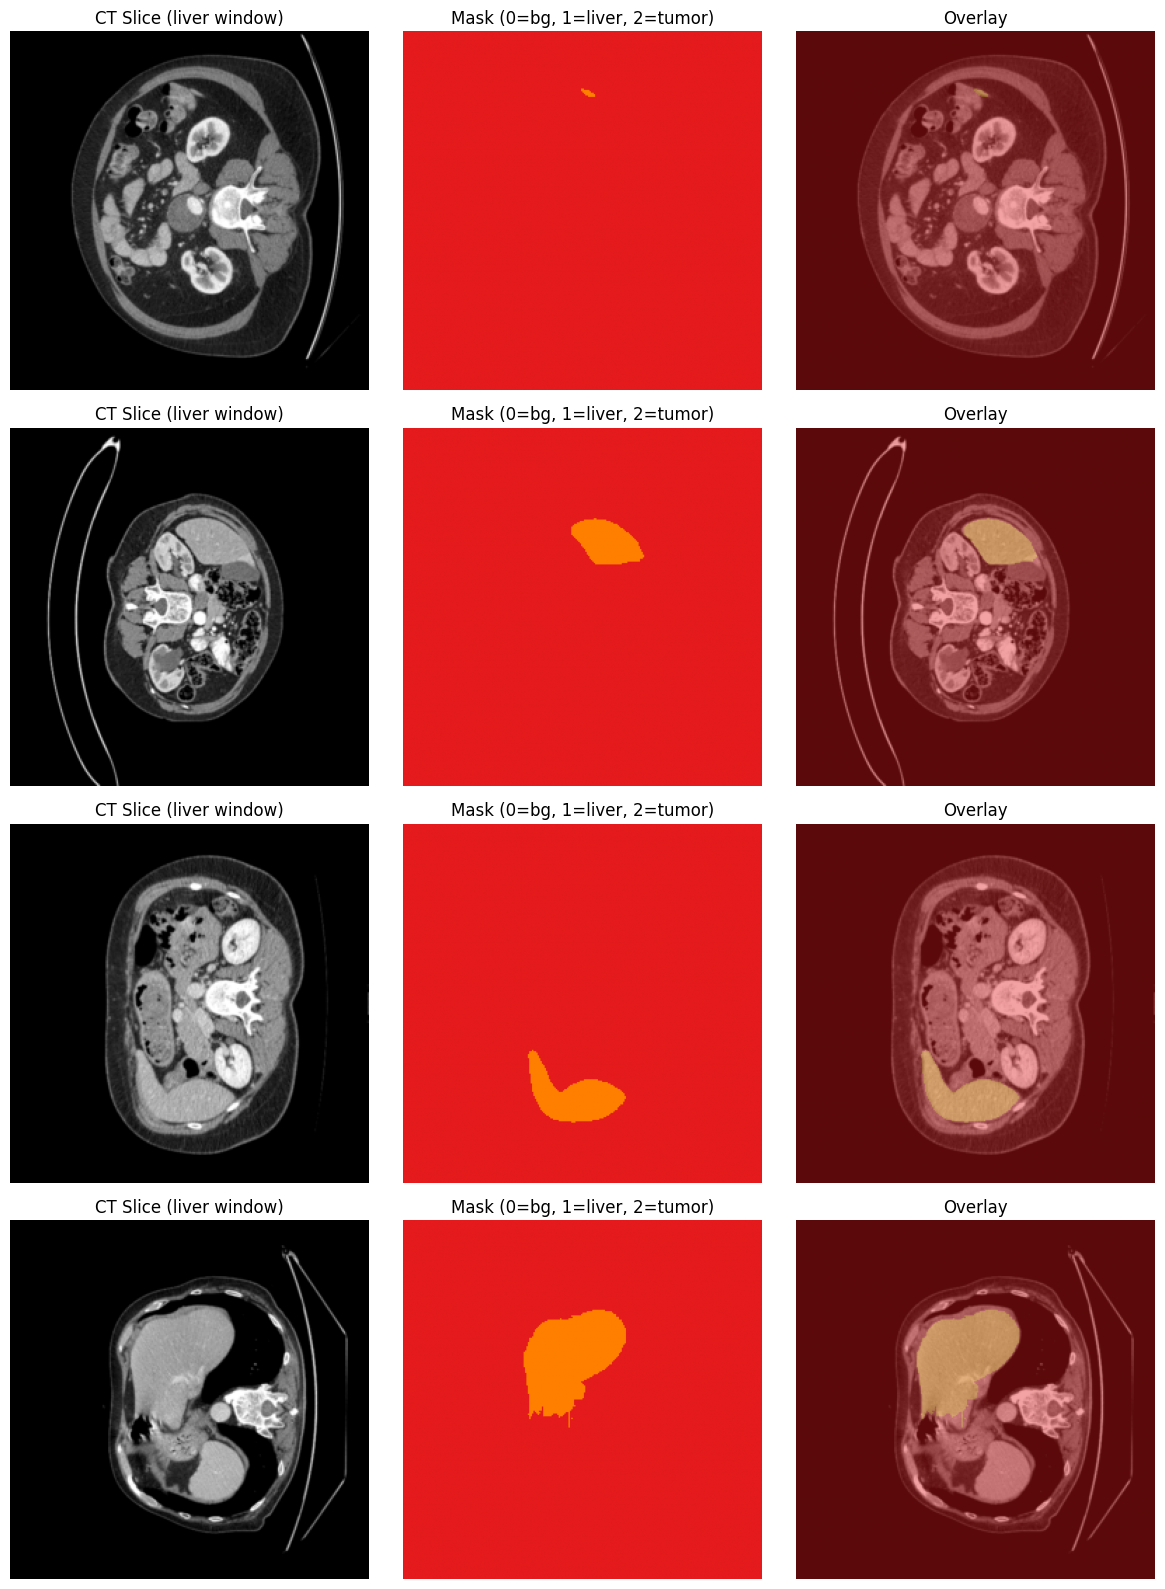

In [4]:
#Displyaing sample CT slices, their masks, and overlay views, then saves the figure.
def plot_samples(dataset, n=4):
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    cmap_mask = plt.cm.get_cmap('Set1', 3)

    for i in range(n):
        img, msk = dataset[i * (len(dataset) // n)]
        img_np = img.squeeze().numpy()
        msk_np = msk.numpy()

        axes[i, 0].imshow(img_np, cmap='gray')
        axes[i, 0].set_title('CT Slice (liver window)')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(msk_np, cmap=cmap_mask, vmin=0, vmax=2)
        axes[i, 1].set_title('Mask (0=bg, 1=liver, 2=tumor)')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(img_np, cmap='gray')
        axes[i, 2].imshow(msk_np, cmap=cmap_mask, alpha=0.4, vmin=0, vmax=2)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('sample_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_samples(train_ds, n=4)

## 5. U-Net Architecture

The baseline model uses the standard U-Net architecture introduced by Ronneberger et al. (2015), adapted here for multi-class medical image segmentation.

A key design feature of this implementation is that the `in_channels` parameter is configurable rather than fixed in the code. In the current baseline setting, `in_channels=1` because each input consists of a single CT slice. This design also makes the architecture easy to extend for future experiments. For example, a multi-window input setup can be handled by setting `in_channels=3`, while a real multi-phase CT setup can be supported by setting `in_channels=4`, without requiring any further structural changes to the model.

In [5]:

#Creating two convolution layers with batch normalization and ReLU activation.
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        norm1 = nn.BatchNorm2d(out_ch)
        act1 = nn.ReLU(inplace=True)

        conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        norm2 = nn.BatchNorm2d(out_ch)
        act2 = nn.ReLU(inplace=True)

        self.block = nn.Sequential(
            conv1,
            norm1,
            act1,
            conv2,
            norm2,
            act2
        )
    def forward(self, x):
        return self.block(x)

class Encoder(nn.Module):
    # Creating encoder blocks and pooling layers for each feature size.
    def __init__(self, in_ch, features):
        super().__init__()
        self.blocks = nn.ModuleList()
        self.pools = nn.ModuleList()

        for f in features:
            new_block = ConvBlock(in_ch, f)
            new_pool = nn.MaxPool2d(2)
            self.blocks.append(new_block)
            self.pools.append(new_pool)
            in_ch = f

    #Passing the input through each encoder block and storing skip connections.
    def forward(self, x):
        skips = []
        for block, pool in zip(self.blocks, self.pools):
            x = block(x)
            current_skip = x
            skips.append(current_skip)
            x = pool(x)
        return x, skips

class Decoder(nn.Module):
    def __init__(self, features):
        # features = [1024, 512, 256, 128, 64]
        # each step: upsample features[i] -> features[i+1]
        # then concat with skip of features[i+1] -> total features[i]
        # then ConvBlock(features[i] -> features[i+1])
        # This constructor creates upsampling layers and convolution blocks for the decoder path.
        super().__init__()
        self.ups = nn.ModuleList()
        self.blocks = nn.ModuleList()

        for i in range(len(features) - 1):
            self.ups.append(
                nn.ConvTranspose2d(features[i], features[i + 1], kernel_size=2, stride=2)
            )
            self.blocks.append(
                ConvBlock(features[i], features[i + 1])
            )

    def forward(self, x, skips):
        # This function upsamples the input, combines it with skip connections, and refines it through decoder blocks.
        skips = skips[::-1]

        for i, (up, block) in enumerate(zip(self.ups, self.blocks)):
            x = up(x)
            skip = skips[i]

            if x.shape != skip.shape:
                x = TF.resize(x, size=skip.shape[2:])

            x = torch.cat([skip, x], dim=1)
            x = block(x)

        return x
    

class UNet(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, num_classes=NUM_CLASSES,
                 features=[64, 128, 256, 512]):
        # Building the full U-Net using an encoder, bottleneck, decoder, and final output layer.
        super().__init__()

        self.encoder = Encoder(in_channels, features)
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        decoder_features = [features[-1] * 2] + features[::-1]
        self.decoder = Decoder(decoder_features)

        self.head = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        #Passing the input through the encoder, bottleneck, decoder, and output head.
        x, skips = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x, skips)
        return self.head(x)


# creating the U-Net model, counts its trainable parameters, and checks input/output tensor shapes:
model = UNet(in_channels=IN_CHANNELS, num_classes=NUM_CLASSES).to(DEVICE)

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f'Model parameters : {total_params:,}')

with torch.no_grad():
    dummy = torch.randn(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE)
    dummy = dummy.to(DEVICE)
    out = model(dummy)

    print(f'Input shape  : {dummy.shape}')
    print(f'Output shape : {out.shape}')

Model parameters : 31,036,611
Input shape  : torch.Size([2, 1, 256, 256])
Output shape : torch.Size([2, 3, 256, 256])


## 6. Loss Function & Metrics

In [6]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        # Constructor to store the smoothing value used to avoid division issues in Dice loss.
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # Dice loss computation by comparing predicted probabilities with one-hot encoded target masks:
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, num_classes=logits.shape[1])
        targets_oh = targets_oh.permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = (probs * targets_oh).sum(dims)
        cardinality = (probs + targets_oh).sum(dims)

        dice_per_class = (2 * intersection + self.smooth) / (cardinality + self.smooth)
        loss = 1 - dice_per_class[1:].mean()

        return loss


class CombinedLoss(nn.Module):
    def __init__(self, ce_weight=0.5, dice_weight=0.5):
        #  weights for cross-entropy and dice loss + creating  both loss functions:
        super().__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        # Calculating the weighted sum of cross-entropy loss and dice loss.
        return (
            self.ce_weight * self.ce(logits, targets)
            + self.dice_weight * self.dice(logits, targets)
        )


def dice_score(logits, targets, smooth=1e-6):
    #Clacultaing  separate Dice scores for the liver and tumor classes.
    preds = logits.argmax(dim=1)
    scores = {}

    for cls, name in {1: 'liver', 2: 'tumor'}.items():
        pred_c = (preds == cls).float()
        true_c = (targets == cls).float()

        multiplied = pred_c * true_c
        intersection = multiplied.sum()

        pred_total = pred_c.sum()
        true_total = true_c.sum()

        numerator = 2 * intersection + smooth
        denominator = pred_total + true_total + smooth

        scores[name] = (numerator / denominator).item()

    return scores


criterion = CombinedLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print('Loss and optimizer ready.')

Loss and optimizer ready.


## 7. Training Loop

In [9]:
import json

if os.path.exists('history.json'):
    with open('history.json', 'r') as f:
        history = json.load(f)
    print(f'Resumed history — {len(history["train_loss"])} epochs already done.')
else:
    history = {'train_loss': [], 'val_loss': [], 'train_liver': [],
               'val_liver': [], 'train_tumor': [], 'val_tumor': []}
    print('Starting fresh history.')

if os.path.exists('checkpoint_latest.pth'):
    model.load_state_dict(torch.load('checkpoint_latest.pth', map_location=DEVICE))
    print('Resumed model weights from checkpoint.')

epochs_done   = len(history['train_loss'])
val_loss_history = history['val_loss']
best_val_loss = min(val_loss_history) if val_loss_history else float('inf')
best_model_path = 'best_unet.pth'
print(f'Training for {NUM_EPOCHS} epochs on {DEVICE}...\n')


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_scores = {'liver': [], 'tumor': []}

    for images, masks in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        with torch.no_grad():
            scores = dice_score(logits, masks)
            for k in all_scores:
                all_scores[k].append(scores[k])

    return total_loss / len(loader), {k: np.mean(v) for k, v in all_scores.items()}


# Global DSC accumulation — avoids per-batch averaging bias
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss  = 0
    liver_ints  = liver_cards = 0.0
    tumor_ints  = tumor_cards = 0.0
    smooth      = 1e-6

    for images, masks in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        logits        = model(images)
        total_loss   += criterion(logits, masks).item()

        preds = logits.argmax(dim=1)
        liver_ints  += ((preds == 1) & (masks == 1)).sum().item()
        liver_cards += ((preds == 1).sum() + (masks == 1).sum()).item()
        tumor_ints  += ((preds == 2) & (masks == 2)).sum().item()
        tumor_cards += ((preds == 2).sum() + (masks == 2).sum()).item()

    scores = {
        'liver': (2 * liver_ints  + smooth) / (liver_cards  + smooth),
        'tumor': (2 * tumor_ints  + smooth) / (tumor_cards  + smooth),
    }
    return total_loss / len(loader), scores


for epoch in range(epochs_done + 1, NUM_EPOCHS + 1):
    train_loss, train_scores = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_scores   = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_liver'].append(train_scores['liver'])
    history['val_liver'].append(val_scores['liver'])
    history['train_tumor'].append(train_scores['tumor'])
    history['val_tumor'].append(val_scores['tumor'])

    with open('history.json', 'w') as f:
        json.dump(history, f)

    torch.save(model.state_dict(), 'checkpoint_latest.pth')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        saved = '  ← saved'
    else:
        saved = ''

    print(
        f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
        f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
        f'Liver DSC: {val_scores["liver"]:.4f} | Tumor DSC: {val_scores["tumor"]:.4f}'
        f'{saved}'
    )


Resumed history — 24 epochs already done.
Resumed model weights from checkpoint.
Training for 30 epochs on cuda...

Epoch 25/30 | Train Loss: 0.0503 | Val Loss: 0.2645 | Liver DSC: 0.9369 | Tumor DSC: 0.4453
Epoch 26/30 | Train Loss: 0.0611 | Val Loss: 0.2760 | Liver DSC: 0.9333 | Tumor DSC: 0.4311
Epoch 27/30 | Train Loss: 0.0473 | Val Loss: 0.2703 | Liver DSC: 0.9368 | Tumor DSC: 0.3929
Epoch 28/30 | Train Loss: 0.0439 | Val Loss: 0.2723 | Liver DSC: 0.9394 | Tumor DSC: 0.3427
Epoch 29/30 | Train Loss: 0.0433 | Val Loss: 0.2684 | Liver DSC: 0.9384 | Tumor DSC: 0.3380
Epoch 30/30 | Train Loss: 0.0458 | Val Loss: 0.2676 | Liver DSC: 0.9398 | Tumor DSC: 0.4017


## 8. Training Curves

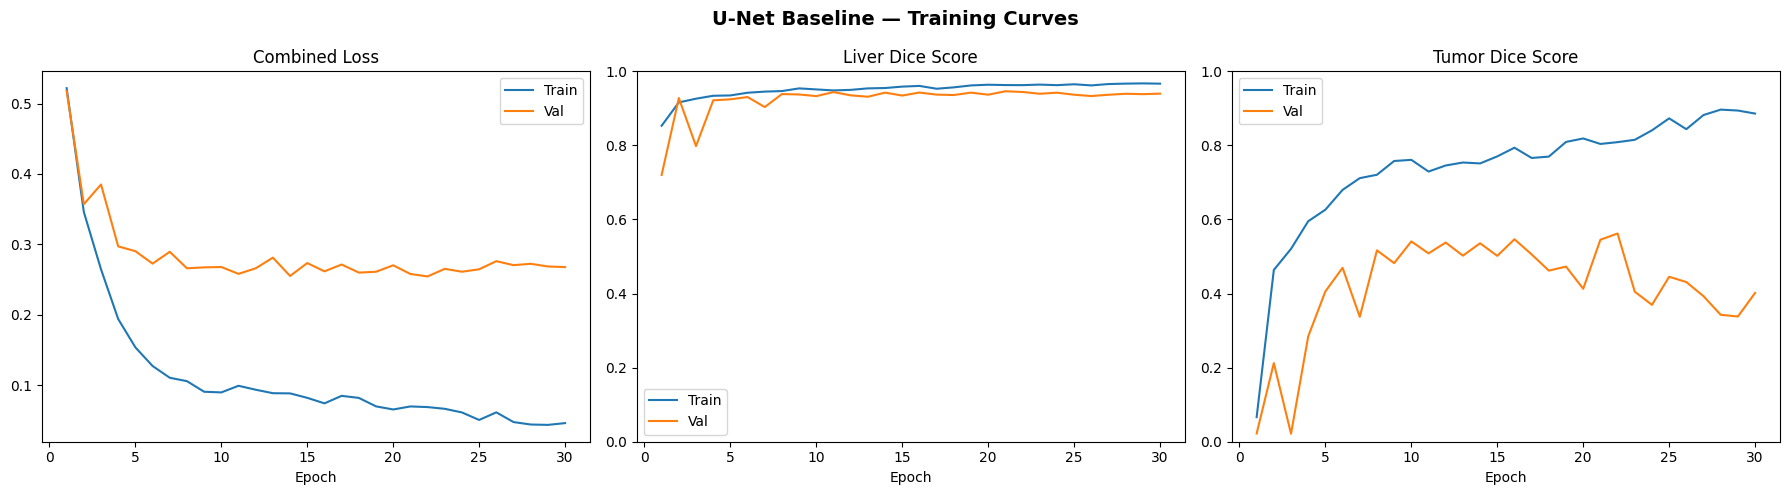

In [10]:
# Plotting the training and validation loss and Dice scores across all epochs.
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Combined Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['train_liver'], label='Train')
axes[1].plot(epochs, history['val_liver'],   label='Val')
axes[1].set_title('Liver Dice Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()

axes[2].plot(epochs, history['train_tumor'], label='Train')
axes[2].plot(epochs, history['val_tumor'],   label='Val')
axes[2].set_title('Tumor Dice Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.suptitle('U-Net Baseline — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Test Set Evaluation (Final Results)

In [11]:
# Loaaing the best saved model + evaluate on teh test set and print the baseline results:
best_weights = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(best_weights)

test_loss, test_scores = evaluate(model, test_loader, criterion)

liver_score = test_scores["liver"]
tumor_score = test_scores["tumor"]
separator = '=' * 50

print(separator)
print('         BASELINE RESULTS (Test Set)')
print(separator)
print(f'  Test Loss  : {test_loss:.4f}')
print(f'  Liver DSC  : {liver_score:.4f}')
print(f'  Tumor DSC  : {tumor_score:.4f}')
print(separator)
print()

print('Reference (LiTS leaderboard, 2D U-Net level):')
print('  Liver DSC  ~ 0.94 - 0.96')
print('  Tumor DSC  ~ 0.50 - 0.65')
print()

print('These numbers are the baseline to beat in the novel extension.')

         BASELINE RESULTS (Test Set)
  Test Loss  : 0.2758
  Liver DSC  : 0.9111
  Tumor DSC  : 0.3360

Reference (LiTS leaderboard, 2D U-Net level):
  Liver DSC  ~ 0.94 - 0.96
  Tumor DSC  ~ 0.50 - 0.65

These numbers are the baseline to beat in the novel extension.


## 10. Qualitative Results

/tmp/ipykernel_55/766331857.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', 3)


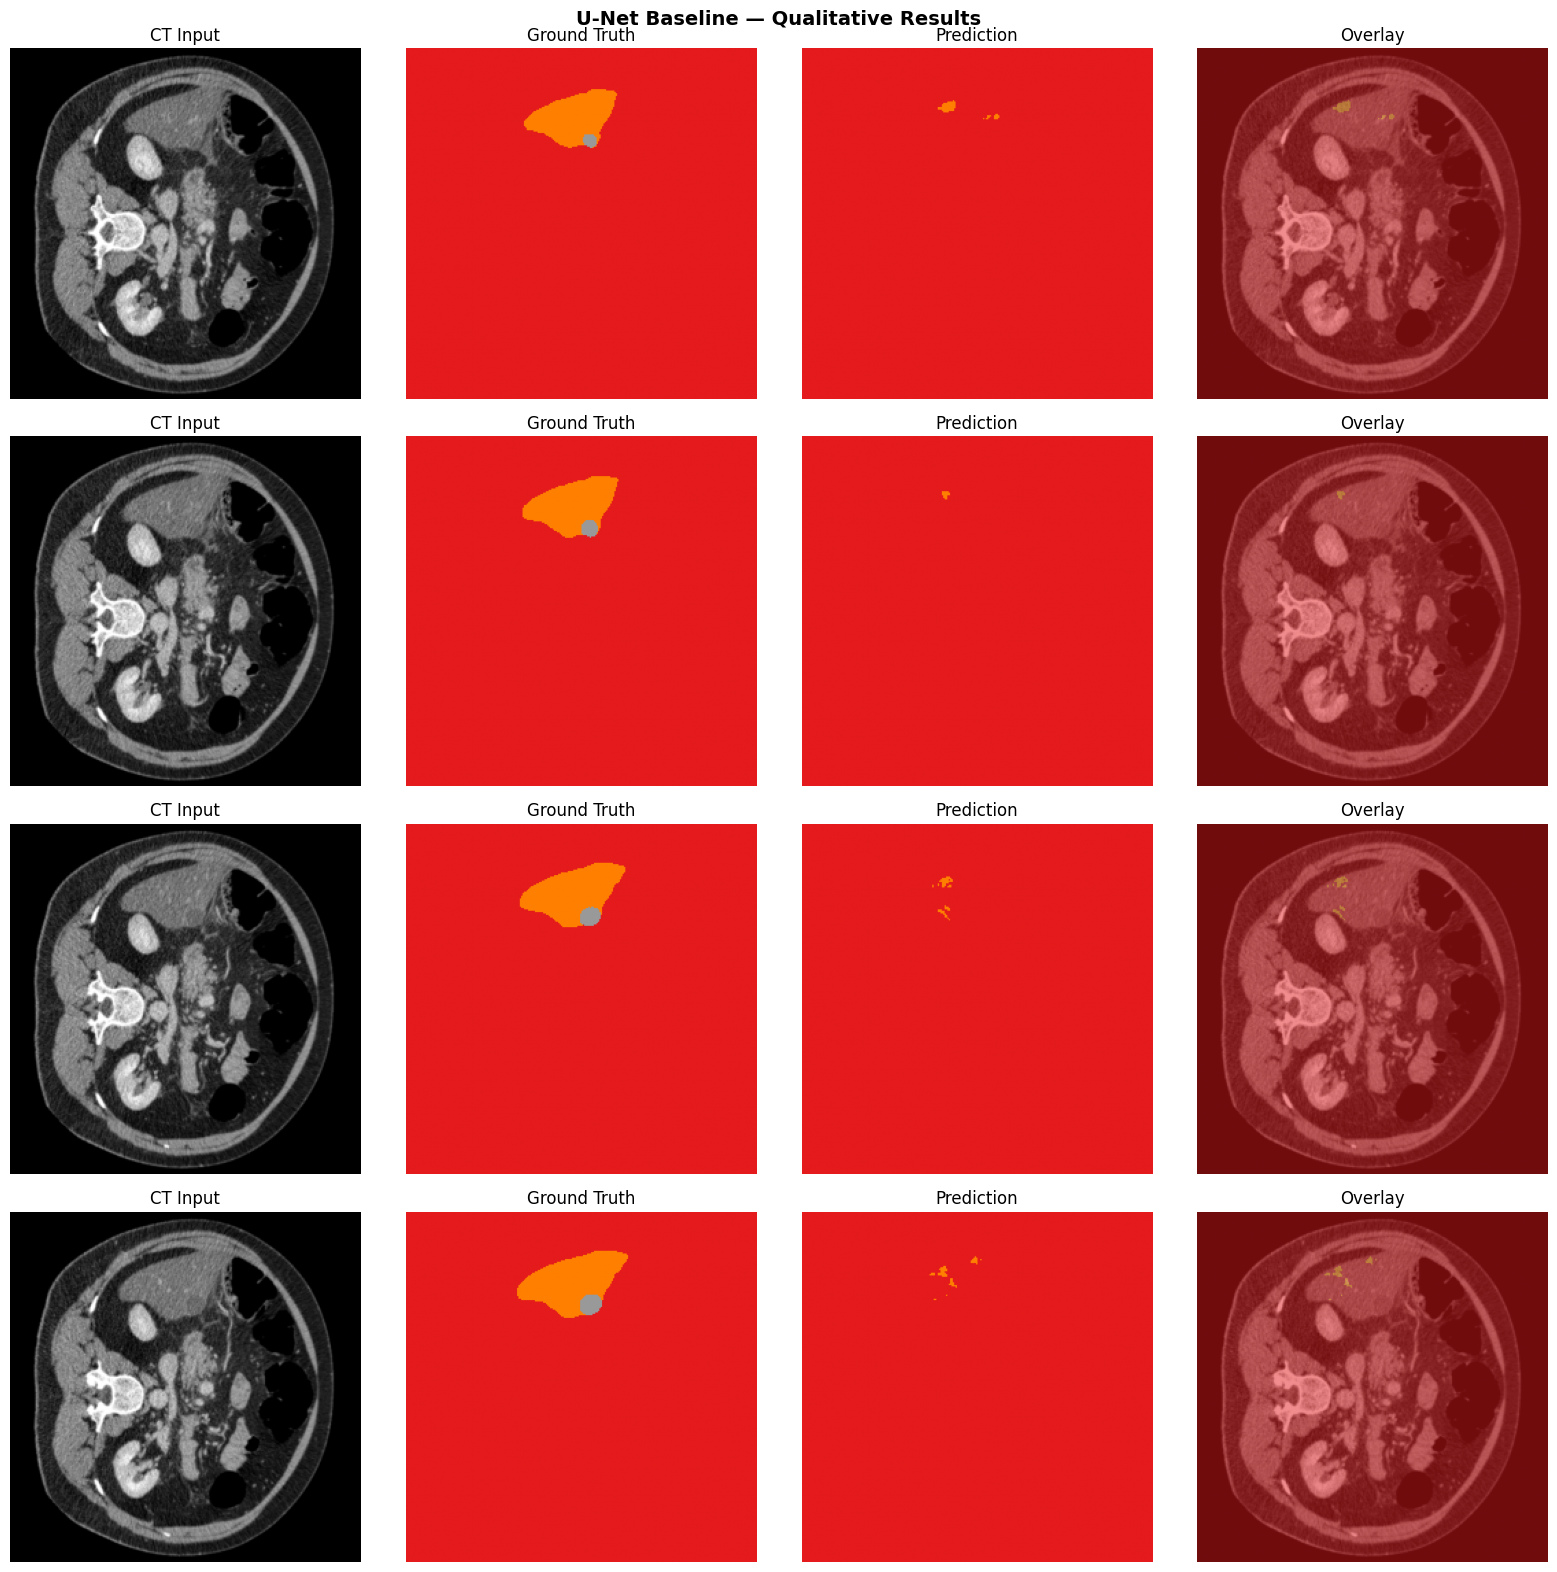

In [12]:
#Finding sample tumor slices + predict masks -> show input, ground truth, prediction, and overlay views.

@torch.no_grad()
def visualize_predictions(model, dataset, n=4):
    model.eval()
    cmap = plt.cm.get_cmap('Set1', 3)
    fig, axes = plt.subplots(n, 4, figsize=(16, n * 4))

    indices = []

    for i in range(len(dataset)):
        _, msk = dataset[i]
        has_tumor = (msk == 2).sum() > 50

        if has_tumor:
            indices.append(i)

        if len(indices) == n:
            break

    for row, idx in enumerate(indices):
        img, msk = dataset[idx]

        logit = model(img.unsqueeze(0).to(DEVICE))
        pred = logit.argmax(dim=1).squeeze().cpu().numpy()

        img_np = img.squeeze().numpy()
        msk_np = msk.numpy()

        items = [
            ('CT Input', img_np, {'cmap': 'gray'}),
            ('Ground Truth', msk_np, {'cmap': cmap, 'vmin': 0, 'vmax': 2}),
            ('Prediction', pred, {'cmap': cmap, 'vmin': 0, 'vmax': 2}),
            ('Overlay', img_np, {'cmap': 'gray'})
        ]

        for col, (title, data, kwargs) in enumerate(items):
            axes[row, col].imshow(data, **kwargs)

            if col == 3:
                axes[row, col].imshow(pred, cmap=cmap, alpha=0.5, vmin=0, vmax=2)

            axes[row, col].set_title(title)
            axes[row, col].axis('off')

    plt.suptitle('U-Net Baseline — Qualitative Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('qualitative_results.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(model, test_ds, n=4)